#### Loading packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf


#### Setting root directory path

In [2]:
ROOT = r'C:\Users\PC_DS_ECON_5\Desktop\data-analytics-python'


#### Data source used: NLSY97

The NLSY97 is a `longitudinal` (i.e. `panel`) survey of individuals born between 1980 and 1984. The first round of data collection took place in 1997 and was followed by additional survey rounds every one or two years.


#### Loading data

Reminder: We need the `pyarrow` package to import a `.parquet` datafile.

In [3]:
nlsy97_income_hours_all_df = pd.read_parquet(ROOT + '/data/nlsy97_income_hours_all_df.parquet')
nlsy97_additional_vars_df = pd.read_parquet(ROOT + '/data/nlsy97_additional_vars_df.parquet')


#### Dictionary of variable labels

In [4]:
long_varlabels_dict = {
    'gender': 'Gender',
    'ethnicity': 'Ethnicity',
    'educ': 'Highest Grade Completed',
    'degree': 'Highest Degree Earned',
    'meduc_bio': 'Highest Grade Completed (Biological Mother)',
    'meduc_res': 'Highest Grade Completed (Residential Mother)',
    'feduc_bio': 'Highest Grade Completed (Biological Father)',
    'feduc_res': 'Highest Grade Completed (Residential Father)',
    'educ_num': 'Inferred Years of Education',
    'educ_cat': 'Highest Degree Earned',
    'meduc_bio_num': 'Inferred Years of Education (Biological Mother)',
    'meduc_res_num': 'Inferred Years of Education (Residential Mother)',
    'feduc_bio_num': 'Inferred Years of Education (Biological Father)',
    'feduc_res_num': 'Inferred Years of Education (Residential Father)',
    'meduc_bio_cat': 'Inferred Degree (Biological Mother)',
    'meduc_res_cat': 'Inferred Degree (Residential Mother)',
    'feduc_bio_cat': 'Inferred Degree (Biological Father)',
    'feduc_res_cat': 'Inferred Degree (Residential Father)',
    'hh_yinc_1997': 'Household Income in 1997',
    'hh_yinc_source_1997': 'Source of Household Income in 1997', 
    'hh_net_worth_1997': 'Household Net Worth in 1997',
    'ASVAB_score': 'ASVAB score percentile (x1000)',
    'ASVAB_pct': 'ASVAB score percentile rank'
}


short_varlabels_dict = {
    'gender': 'Gender',
    'ethnicity': 'Ethnicity',
    'educ': 'Highest Grade Completed',
    'degree': 'Highest Degree Earned',
    'meduc_bio': 'Highest Grade Compl. (Biol. Mother)',
    'meduc_res': 'Highest Grade Compl. (Resid. Mother)',
    'feduc_bio': 'Highest Grade Compl. (Biol. Father)',
    'feduc_res': 'Highest Grade Compl. (Resid. Father)',
    'educ_num': 'Inferred Years of Educ.',
    'educ_cat': 'Highest Degree Earned',
    'meduc_bio_num': 'Inferred Years of Educ. (Biol. Mother)',
    'meduc_res_num': 'Inferred Years of Educ. (Resid. Mother)',
    'feduc_bio_num': 'Inferred Years of Educ. (Biol. Father)',
    'feduc_res_num': 'Inferred Years of Educ. (Resid. Father)',
    'meduc_bio_cat': 'Inferred Highest Degree (Biol. Mother)',
    'meduc_res_cat': 'Inferred Highest Degree (Resid. Mother)',
    'feduc_bio_cat': 'Inferred Highest Degree (Biol. Father)',
    'feduc_res_cat': 'Inferred Highest Degree (Resid. Father)',
    'hh_yinc_1997': 'HH Income in 1997',
    'hh_yinc_source_1997': 'Source of HH Income in 1997', 
    'hh_net_worth_1997': 'HH Net Worth in 1997',
    'ASVAB_score': 'ASVAB score ptile (x1000)',
    'ASVAB_pct': 'ASVAB score ptile rank'
}

##### Preparing the variables

As in the previous section on correlation, we will use the following variables:

- log hourly pay (in 2023)
- educational attainment categories (highest degree / grade completed)
- ASVAB test score percentile rank (in 1997)

First, let us construct hourly pay `hpay` from annual income and annual hours worked in 2023. We then calculate the natural logarithm of hourly pay, `log_hpay`.

In [5]:
df = nlsy97_income_hours_all_df.copy()

df = df.loc[df['year'].eq(2023),['person_id', 'yinc', 'yhours']].copy()

valid = (
    df['yinc'].notna() &
    df['yhours'].notna() &
    df['yinc'].ne(0) &
    df['yhours'].ne(0)
)

df['hpay'] = np.where(valid,
                      df['yinc'] / df['yhours'],
                      pd.NA)

df = df.convert_dtypes()
df['log_hpay'] = np.where(df['hpay'].gt(0) & df['hpay'].notna(),
                          np.log(df['hpay']),
                          pd.NA)
df = df.convert_dtypes()
inc_df = df.copy()

Second, let us use the same educational attainment categories as in previous examples.

For study participants, we construct the educational attainment categories in the following way:

$$
educ\_cat = 
\begin{cases}
\text{Less than High School} & \text{if } degree = \text{No degree} \text{ or } degree = \text{GED}\\
\text{High School} & \text{if } degree = \text{High school} \text{ and } educ\_num \leq 12\\
\text{Some College} & \text{if } (degree = \text{High school} \text{ and } educ\_num > 12) \text{ or } degree = \text{Junior college}\\
\text{Bachelor Plus} & \text{if } degree \in \{\text{Bachelor}, \text{Master}, \text{Professional}, \text{PhD}\}
\end{cases}
$$

For parents, we construct the educational attainment categories in the following way:

$$
[m/f]educ\_cat = 
\begin{cases}
\text{Less than High School} & \text{if } [m/f]educ\_num \leq 11\\
\text{High School} & \text{if } [m/f]educ\_num = 12\\
\text{Some College} & \text{if } [m/f]educ\_num \in [13,15] \\
\text{Bachelor Plus} & \text{if } [m/f]educ\_num \geq 16
\end{cases}
$$

In [6]:
df = nlsy97_additional_vars_df.copy()
varnames = ['meduc_bio', 'meduc_res', 'feduc_bio', 'feduc_res']
categories = ['Less than High School', 'High School', 'Some College', 'Bachelor Plus']
for varname in varnames:
    df[varname + '_cat'] = pd.NA 
    df.loc[df[varname + '_num'].lt(12), varname + '_cat'] = categories[0]
    df.loc[df[varname + '_num'].eq(12), varname + '_cat'] = categories[1]
    df.loc[df[varname + '_num'].gt(12) & df[varname + '_num'].lt(16), varname + '_cat'] = categories[2]
    df.loc[df[varname + '_num'].ge(16), varname + '_cat'] = categories[3]
    df[varname + '_cat'] = pd.Categorical(df[varname + '_cat'], categories=categories, ordered=True)


df['educ_cat'] = pd.NA
df.loc[df['degree'].eq('No degree'), 'educ_cat'] = categories[0]
df.loc[df['degree'].eq('GED'), 'educ_cat'] = categories[0]
df.loc[df['degree'].eq('High school') & df['educ_num'].le(12), 'educ_cat'] = categories[1]
df.loc[df['degree'].eq('High school') & df['educ_num'].gt(12), 'educ_cat'] = categories[2]
df.loc[df['degree'].eq('Junior college'), 'educ_cat'] = categories[2]
df.loc[df['degree'].eq('Bachelor'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('Master'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('Professional'), 'educ_cat'] = categories[3]
df.loc[df['degree'].eq('PhD'), 'educ_cat'] = categories[3]
df['educ_cat'] = pd.Categorical(df['educ_cat'], categories=categories, ordered=True)

nlsy97_additional_vars_df = df.copy()

Third, let us prepare the variable `ASVAB_pct`, which measures each participant's ASVAB test score percentile rank in 1997.

In [7]:
df = nlsy97_additional_vars_df.copy()
df['ASVAB_pct'] = df['ASVAB_score'] / 1000
df = df.convert_dtypes()
nlsy97_additional_vars_df = df.copy()

Finally, we merge the data frame `nlsy97_additional_vars_df` containing the demographic, test percentile, and educational variables with the data frame `inc_df` containing hourly pay and log hourly pay.

In [8]:
merged_df = pd.merge(left=nlsy97_additional_vars_df,
                     right=inc_df,
                     on='person_id',
                     how='left')

#### Simple linear regression

##### Scatterplot of log hourly pay and ASVAB test score percentile rank

Let us begin with a scatter plot of log hourly pay against ASVAB test score percentile rank.

Text(0.5, 0, 'ASVAB test score percentile rank in 1997')

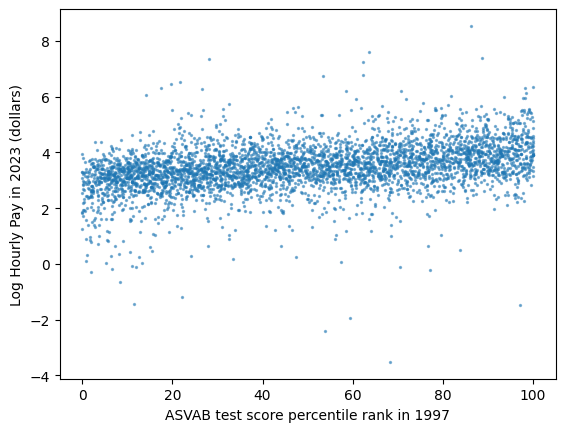

In [9]:
df = merged_df.copy()

fig, ax = plt.subplots()
# scatter plot
# logarithm of hourly pay as the outcome (vertical y-axis)
# ASVAB test score percentile rank (horizontal x-axis)
ax.scatter(x=df['ASVAB_pct'], y=df['log_hpay'], s=2, alpha=0.5)
# yticksvalues = [1, 10, 100, 1000]
# yticksvalues_log = np.log(yticksvalues)
# yticksvalues_labels = np.array(yticksvalues).astype(str)
# ax.set_yticks(ticks=yticksvalues_log, labels=yticksvalues_labels)
ax.set_ylabel('Log Hourly Pay in 2023 (dollars)', fontsize=10)
ax.set_xlabel('ASVAB test score percentile rank in 1997')



Visually, there appears to be a positive relationship: individuals with higher ASVAB percentile ranks tend to have higher hourly pay.

The relationship is far from deterministic. There is substantial variation in hourly pay even among individuals with similar ASVAB scores.

To visualise the average relationship more clearly, let us consider the conditional mean of log hourly pay by ASVAB percentile rank bins, as we have done before.

Text(0.5, 0, 'ASVAB test score percentile rank in 1997')

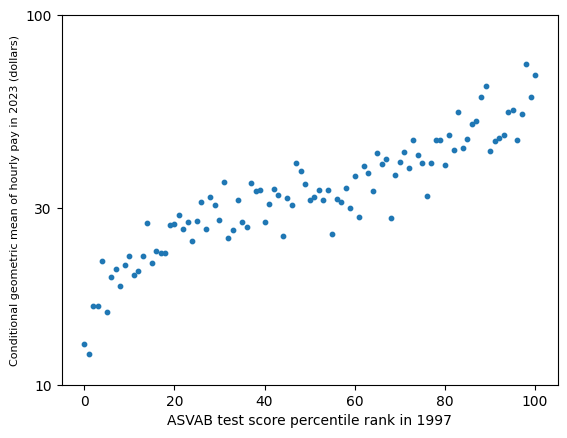

In [10]:
df = merged_df.copy()

df['ASVAB_pct_bin'] = np.floor(df['ASVAB_pct'])


plot_df = df.groupby(by='ASVAB_pct_bin').agg(mean_log_hpay = ('log_hpay', 'mean')).reset_index().copy()

plot_df = plot_df.convert_dtypes()
plot_df
fig, ax = plt.subplots()

ax.scatter(x=plot_df['ASVAB_pct_bin'], y=plot_df['mean_log_hpay'], s=10)

y_tickvalues = np.array([10,30,100])
y_tickvalues_log = np.log(y_tickvalues) 
y_tickvalues_str = y_tickvalues.astype(str)
ax.yaxis.set_ticks(ticks=y_tickvalues_log, labels=y_tickvalues_str)

ax.set_ylabel('Conditional geometric mean of hourly pay in 2023 (dollars)', fontsize=8)
ax.set_xlabel('ASVAB test score percentile rank in 1997')


The conditional mean plot confirms the positive association, but points to a non-linear relationship.

The population counterpart of the conditional mean plot is the conditional mean function:

$$
\mathbb{E}[log\_hpay \mid ASVAB\_pct]
$$

**Linear regression as linear approximation of the conditional mean function**

Linear regression approximates the conditional mean function using a straight line. Although the true conditional mean function may be non-linear, a **linear approximation** often provides a useful summary of the **average relationship** between two variables.

**Simple** linear regression means that there is **only one** conditioning variable, called **regressor**.

In the case of simple linear regression, the approximation corresponds to:

$$
\mathbb{E}[Y \mid X]\ \approx\ \overbrace{\beta_0}^{\mathclap{\substack{\text{intercept}\\ \text{parameter}}}}  
\ \ +\ \ \overbrace{\beta_1}^{\mathclap{\substack{\text{slope}\\ \text{coefficient}\\ \text{parameter}}}} 
\cdot \underbrace{X}_{\mathclap{\substack{\text{regressor}}}} 
$$

**Ordinary Least Squares in the case of Simple Linear Regression**

What is the best-fitting linear function? 
 - We need a criteria: **minimising a loss function**.
 - The **most common** loss criterion is the **mean of squared errors**:

$$
(\beta_0, \beta_1) = \arg \underset{(b_0, b_1)}{\min} \  \mathbb{E}\left[\left(Y - (b_0 + b_1 \cdot X)\right)^2\right] 
$$

This minimisation is the population version of the **Ordinary Least Squares (OLS)** problem. The use of squared errors is not arbitrary. In fact, the population mean can be characterized as the value that minimizes the expected squared deviation:

$$
\mathbb{E}[Y] = \arg \underset{m}{\min} \ \mathbb{E}\left[\left(Y - m\right)^2\right]
$$

Linear regression extends this idea from finding the best constant predictor to **finding the best linear predictor**.

In the population, the deviation between the value of the outcome variable and the linear prediction for the conditional mean is called the **error term**:

$$
\underbrace{\varepsilon}_{\mathclap{\substack{\text{error}\\ \text{term}}}}\ =\ \underbrace{Y}_{\mathclap{\substack{\text{outcome}}}} - \underbrace{(\beta_0 + \beta_1 \cdot X)}_{\mathclap{\substack{\text{linear prediction}}}} 
\ \ \ \ \ \Longleftrightarrow \ \ \ \ \  
\underbrace{Y}_{\mathclap{\substack{\text{outcome}}}}\ =\ \underbrace{\beta_0 + \beta_1 \cdot X}_{\mathclap{\substack{\text{linear prediction}}}} + \underbrace{\varepsilon}_{\mathclap{\substack{\text{error}\\ \text{term}}}}
$$

In the case of simple linear regression, after solving the OLS minimisation, we obtain the following results for the parameter values of the best linear approximation:

$$
\begin{array}{rcll}
\beta_0 &=& \mathbb{E}[Y] - \beta_1 \cdot \mathbb{E}[X] & \ \ (\text{intercept}) \\ \\
\beta_1 &=& \displaystyle \frac{Cov(X,Y)}{Var(X)}                     &  \ \ (\text{slope coefficient})
\end{array}
$$

The slope coefficient is equal to the correlation coefficient times the ratio of standard deviations:

$$
\beta_1 
= \frac{Cov(X,Y)}{Var(X)} 
= \frac{Cov(X,Y)}{(SD(X))^2} 
= \frac{Cov(X,Y)}{SD(X)}\cdot \frac{1}{SD(X)} 
= \frac{Cov(X,Y)}{SD(X)\cdot SD(Y)}\cdot \frac{SD(Y)}{SD(X)}
= Corr(X,Y) \cdot \frac{SD(Y)}{SD(X)}
$$

The solution to the minimisation problem satisfies two additional properties:

 - The mean of prediction errors is zero: 
$$
\mathbb{E}[\varepsilon] = 0
$$
 - The regressor and the error term are uncorrelated:
$$
Cov(X, \varepsilon) = 0
$$



**Applying Ordinary Least Squares to our example**

In our example, the population linear approximation can be written as:

$$
log\_hpay \ =\ \beta_0 + \beta_1 \cdot ASVAB\_pct + \varepsilon
$$

The sample OLS procedure is the sample analogue of the population least squares problem.

When implementing the procedure, we work with **residuals** instead of an error term for the difference between actual outcome and linear prediction.

The candidate residuals as a function of candidate linear prediction parameters $(b_0, b_1)$ are:

$$
u_{i}(b_0, b_1) = log\_hpay_{i} - (b_0 + b_1 \cdot ASVAB\_pct_{i}) \ \ \ (\text{for each } i \in Sample)
$$

In particular, the OLS minimisation corresponds to **minimising the mean of squared residuals**:

$$
\begin{array}{crcl}
&
(\widehat{\beta}_0, \widehat{\beta}_1) 
&=& \arg \underset{(b_0, b_1)}{\min} \  \displaystyle\frac{1}{N} \sum_{i \in Sample} \left(u_{i}(b_0, b_1)\right)^2 \\ \\
\Longleftrightarrow &
(\widehat{\beta}_0, \widehat{\beta}_1) 
&=& \arg \underset{(b_0, b_1)}{\min} \  \displaystyle\frac{1}{N} \sum_{i \in Sample} \left(log\_hpay_{i} - (b_0 + b_1 \cdot ASVAB\_pct_{i})\right)^2 
\end{array}
$$

The resulting parameter estimates are:

$$
\begin{array}{rcll}
\widehat{\beta}_0 &=& \displaystyle \frac{1}{N} \sum_{i \in Sample} log\_hpay_{i} - \widehat{\beta}_1 \cdot \frac{1}{N} \sum_{i \in \text{Sample}} ASVAB\_pct_{i} & \ \ (\text{intercept}) \\ \\
\widehat{\beta}_1 &=& \displaystyle \frac{Cov_{Sample}(ASVAB\_pct,log\_hpay)}{Var_{Sample}(ASVAB\_pct)}  &  \ \ (\text{slope coefficient})
\end{array}
$$

The estimated equation can be written as:

$$
\underbrace{log\_hpay_{i}}_{\mathclap{\substack{\text{actual outcome}}}} \ =\  \widehat{\beta}_0 + \widehat{\beta}_1 \cdot \underbrace{ASVAB\_pct_{i}}_{\mathclap{\substack{\text{regressor}}}} + \underbrace{\widehat{u}_{i}}_{\mathclap{\substack{\text{residual}}}}
$$

And the predicted value of log hourly pay for individual $i$ corresponds to:

$$
\underbrace{\widehat{log\_hpay}_{i}}_{\mathclap{\substack{\text{predicted outcome}}}} 
\ =\ \underbrace{log\_hpay_{i}}_{\mathclap{\substack{\text{actual outcome}}}} - \underbrace{\widehat{u}_{i}}_{\mathclap{\substack{\text{residual}}}} 
\ =\ \widehat{\beta}_0 + \widehat{\beta}_1 \cdot \underbrace{ASVAB\_pct_{i}}_{\mathclap{\substack{\text{regressor}}}} 

$$

The solution to the minimisation problem satisfies the sample counterparts of the two properties seen above in the case of the population OLS:

 - The mean of residuals is zero: 
$$
\displaystyle \frac{1}{N} \sum_{i \in Sample} \widehat{u}_{i} = 0
$$
 - The regressor and the residuals are uncorrelated:
$$
Cov_{Sample}(ASVAB\_pct, \widehat{u}) = 0
$$





Let us now run the OLS procedure for our example using our sample data.

We first use the `statsmodels.regression.linear_model.OLS` class directly.

To create an OLS model object, we need:

 - the array for the outcome variable $y$ (`log_hpay`)
 - the array for the regressor variable(s) $X$ (here only `ASVAB_pct`)
 - to add a constant to the regressor array $X$ in order to include an intercept in the model

We can then call the `fit()` method of the model object to estimate the regression coefficients and store the results in an object called `results`.

In [11]:
df = merged_df.copy()

# selecting and preparing
varnames = ['log_hpay', 'ASVAB_pct']
# dropping observations with missing values 
# --> observations with both variables non-missing 
df = df[varnames].dropna().copy()
df = df.astype(float)

# outcome variable
y = df['log_hpay']
# array of regressor(s)
X = df[['ASVAB_pct']]
# here just one column / variable because simple linear regression


# add a constant to have an intercept
X = sm.add_constant(X)

# running OLS and saving the results in the object results
results = sm.OLS(y, X).fit()

# print the regression table with all model stats
print(results.summary())

# # print all results attributes
# [attr for attr in dir(results) if not attr.startswith('_')]

                            OLS Regression Results                            
Dep. Variable:               log_hpay   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     649.4
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          6.69e-133
Time:                        19:33:27   Log-Likelihood:                -4693.3
No. Observations:                4012   AIC:                             9391.
Df Residuals:                    4010   BIC:                             9403.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9409      0.024    121.405      0.0

In [12]:
# intercept
beta_0_hat = results.params['const']
# slope
beta_1_hat = results.params['ASVAB_pct']

print('intercept:', beta_0_hat, 'slope:', beta_1_hat)


intercept: 2.940896209174517 slope: 0.010836751842031561


An alternative approach is to specify the regression model using the formula interface `smf`. This syntax may look familiar to users of the `lm()` function in R.

In [13]:
df = merged_df.copy()
df = df[['log_hpay', 'ASVAB_pct']].dropna().copy()

results_f = smf.ols(
    formula='log_hpay ~ ASVAB_pct',
    data=df
).fit()

print(results_f.summary())

                            OLS Regression Results                            
Dep. Variable:               log_hpay   R-squared:                       0.139
Model:                            OLS   Adj. R-squared:                  0.139
Method:                 Least Squares   F-statistic:                     649.4
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          6.69e-133
Time:                        19:33:29   Log-Likelihood:                -4693.3
No. Observations:                4012   AIC:                             9391.
Df Residuals:                    4010   BIC:                             9403.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9409      0.024    121.405      0.0

Let us check that the two approaches produce equivalent results:

In [14]:
np.allclose(
    results.params,
    results_f.params
)

True

**Estimated regression line**

The OLS linear approximation of the conditional mean function is:

$$
\underbrace{\widehat{log\_hpay}_{i}}_{\mathclap{\substack{\text{predicted outcome}}}} \ =\ 2.94 + 0.0108 \cdot \underbrace{ASVAB\_pct_{i}}_{\mathclap{\substack{\text{regressor}}}} 
$$



Let us plot the regression line of predicted values on our scatter plot:

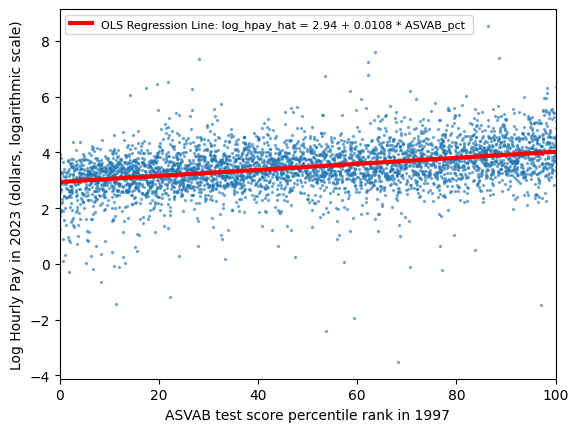

In [15]:
df = merged_df.copy()

# values for the regressor for which to predict the outcome
# --> serves as the regression line
predict_df = pd.DataFrame({'ASVAB_pct': np.linspace(start=df['ASVAB_pct'].min(), stop=df['ASVAB_pct'].max(),num=100)})
# beta_1_hat
slope = results_f.params['ASVAB_pct']
# beta_0_hat
intercept = results_f.params['Intercept']

# predicted values for log hourly income based on the regressor  
predict_df['log_hpay_hat'] = intercept + slope * predict_df['ASVAB_pct']


# predict_df['log_hpay_hat'] = results_f.predict(predict_df) 

fig, ax = plt.subplots()
# plotting the original data (scatter plot)
ax.scatter(x=df['ASVAB_pct'], y=df['log_hpay'], s=2, alpha=0.5)
# adding the regression line
ax.plot(predict_df['ASVAB_pct'], predict_df['log_hpay_hat'], label=f"OLS Regression Line: log_hpay_hat = {intercept:0.2f} + {slope:0.4f} * ASVAB_pct ", color='red',linewidth=3)

ax.set_ylabel('Log Hourly Pay in 2023 (dollars, logarithmic scale)', fontsize=10)
ax.set_xlabel('ASVAB test score percentile rank in 1997')
ax.set_xlim(left=0, right=100)


ax.legend(fontsize=8)

Let us verify that the statsmodels interface gives the same values as the formulas.

In [16]:
df = merged_df.copy()
df = df[['log_hpay', 'ASVAB_pct']].dropna(axis=0, how='any').copy()
df = df.astype(float)


# slope -> covariance between outcome and regressor / variance of the regressor
covariance = df['ASVAB_pct'].cov(df['log_hpay'], ddof=1)
covariance

variance_X = df['ASVAB_pct'].var(ddof=1)
variance_X

slope_by_hand = covariance / variance_X
slope_by_hand

# intercept -> mean the outcome minus the slope coefficient times the mean of the regressor

intercept_by_hand = df['log_hpay'].mean() - slope_by_hand * df['ASVAB_pct'].mean()
intercept_by_hand

print('Intercept "by hand":',
      intercept_by_hand,
      '\nIntercept interface:',
      results_f.params['Intercept'],
      '\n\nSlope coefficient "by hand"',
      slope_by_hand,
      '\nSlope coefficient interface:',
      results_f.params['ASVAB_pct'])


Intercept "by hand": 2.9408962091745203 
Intercept interface: 2.940896209174517 

Slope coefficient "by hand" 0.010836751842031577 
Slope coefficient interface: 0.010836751842031561


**Interpretation of parameter estimates**

Let us remind ourselves that the original objective was an approximation of the conditional mean function.

So let us plot 
 - the conditional means of log hourly pay by ASVAB test score percentile bins again 
 - together with the estimated regression line.

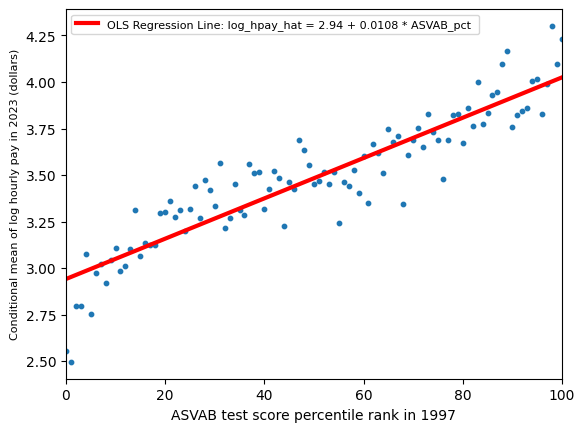

In [17]:
df = merged_df.copy()
df = df[['log_hpay', 'ASVAB_pct']].dropna(axis=0, how='any').copy()
df = df.astype(float)

# conditional mean of log hourly pay by ASVAB test score percentile bin
# percentile bins
df['ASVAB_pct_bin'] = np.floor(df['ASVAB_pct'])
# conditional means
plot_df = df.groupby(by='ASVAB_pct_bin').agg(mean_log_hpay = ('log_hpay', 'mean')).reset_index().copy()
plot_df = plot_df.convert_dtypes().sort_values(by='ASVAB_pct_bin')

# for each ASVAB test score percentile bin (interval of the regressor)
# predict the value of log hourly pay (outcome)
# based on the linear approximation (regression line)
predict_df = plot_df.rename(columns={'ASVAB_pct_bin': 'ASVAB_pct'}).copy()
predict_df['log_hpay_hat'] = results_f.predict(predict_df['ASVAB_pct'])

fig, ax = plt.subplots()

# plotting the non-parametric conditional means
ax.scatter(x=plot_df['ASVAB_pct_bin'], y=plot_df['mean_log_hpay'], s=10)

# parametric linear approximation
slope = results_f.params['ASVAB_pct']
intercept = results_f.params['Intercept']
ax.plot(predict_df['ASVAB_pct'], predict_df['log_hpay_hat'], label=f"OLS Regression Line: log_hpay_hat = {intercept:0.2f} + {slope:0.4f} * ASVAB_pct ", color='red',linewidth=3)


ax.set_ylabel('Conditional mean of log hourly pay in 2023 (dollars)', fontsize=8)
ax.set_xlabel('ASVAB test score percentile rank in 1997')

ax.set_xlim(left=0, right=100)
ax.legend(fontsize=8)



**Interpretation of parameter estimates**

In our example, the estimated regression equation is:

$$
\underbrace{\widehat{log\_hpay}}_{\mathclap{\substack{\text{predicted outcome}}}}
=
2.94
+
0.0108
\cdot
\underbrace{ASVAB\_pct}_{\mathclap{\substack{\text{regressor}}}}
$$

The OLS regression line is therefore a linear approximation of the conditional mean of log hourly pay given the ASVAB test score percentile rank.

**Interpretation of the intercept**

What is the interpretation of the intercept $\widehat{\beta}_0 \approx 2.94$?

The intercept is the predicted value of log hourly pay for individuals whose ASVAB test score percentile rank is zero.

In this example, this means that the model predicts a log hourly pay of approximately 2.94 for individuals at the bottom of the ASVAB percentile rank distribution.

The meaningfulness of the intercept is often limited, especially if the regressor cannot realistically take the value zero or if zero lies outside the range of observed values.

**Interpretation of the slope coefficient**

What is the interpretation of the slope coefficient $\widehat{\beta}_1 \approx 0.0108$?

The slope coefficient is the average change in the predicted value of the outcome variable associated with a one-unit increase in the regressor.

In this example, scoring one percentile point higher on the ASVAB test is associated with an increase of approximately 0.0108 in predicted log hourly pay.

Since the outcome variable is measured in logarithms, we can approximately interpret the coefficient as a percentage change in hourly pay (after multiplying by $100$). For small values of $v$, we can use the approximation

$$
e^v \approx 1 + v\quad \Longleftrightarrow \quad \ln(1 + v) \approx v
$$

The linear prediction is

$$
\widehat{log\_hpay}
=
2.94
+
0.0108
\cdot
ASVAB\_pct.
$$

Exponentiating both sides gives the predicted hourly pay:

$$
\widehat{hpay}
=
e^{2.94 + 0.0108 \cdot ASVAB\_pct}.
$$

Now consider increasing the ASVAB test score percentile rank by one point.

The predicted proportional change in hourly pay is

$$
\frac{\widehat{hpay}_{new}-\widehat{hpay}}
{\widehat{hpay}}
=
\frac{
e^{2.94+0.0108(ASVAB\_pct+1)}
-
e^{2.94+0.0108ASVAB\_pct}
}
{e^{2.94+0.0108ASVAB\_pct}}.
$$

Using the properties of exponentials ($e^{a+b}=e^ae^b$), this simplifies to

$$
\frac{\widehat{hpay}_{new}-\widehat{hpay}}
{\widehat{hpay}}
=
e^{0.0108}-1.
$$

Using the approximation $e^v \approx 1+v$ for small values of $v$ gives

$$
e^{0.0108}-1
\approx
0.0108
=
1.08\%.
$$

Therefore, according to the estimated regression model, scoring one percentile point higher on the ASVAB test is associated with approximately **1.08% higher predicted hourly pay**, on average.

The exact proportional change is

$$
e^{0.0108}-1
\approx
1.09\%.
$$

The approximate and exact interpretations are almost identical because the estimated coefficient is small.

In [18]:
slope = results_f.params['ASVAB_pct']
print(np.exp(slope) - 1, slope)

0.010895682115817484 0.010836751842031561


The OLS residuals are by construction uncorrelated with the regressors used in the model:

$$
Cov_{Sample}(ASVAB\_pct, \widehat{u}) = 0
$$

This is a mechanical property of the OLS estimation procedure.

This does not imply however that the residuals are mean independent from the regressors.

Let us see these properties both visually and numerically.

Let us start with a scatter plot of residuals against regressor values.

Text(0.5, 0, 'ASVAB test score percentile rank in 1997')

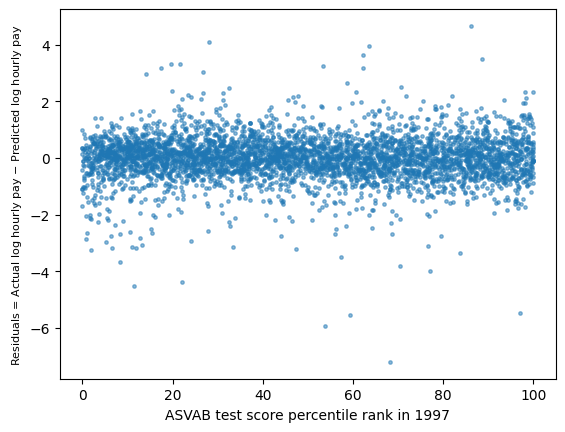

In [19]:
df = merged_df.copy()

# preparing the dataframe
df = df[['log_hpay', 'ASVAB_pct']].dropna(axis=0, how='any').sort_values(by='ASVAB_pct').copy()

# predicting the outcome -> predicted values
df['log_hpay_hat'] = results_f.predict(df)

# computing the residuals: actual value of the outcome minus predicted value of the outcome
df['residuals'] = df['log_hpay'] - df['log_hpay_hat']



fig, ax = plt.subplots()

# scatter plot: 
# vertical axis: residuals (log_hpay - log_hpay_hat)
# horizontal axis: regressor (ASVAB_pct)
ax.scatter(x=df['ASVAB_pct'], y=df['residuals'], s=6, alpha=0.5)
ax.set_ylabel('Residuals = Actual log hourly pay $-$ Predicted log hourly pay', fontsize=8)
ax.set_xlabel('ASVAB test score percentile rank in 1997')


Let us now look plot the conditional mean residual per ASVAB test score percentile rank (regressor) bin.

Text(0.5, 0, 'ASVAB test score percentile rank in 1997')

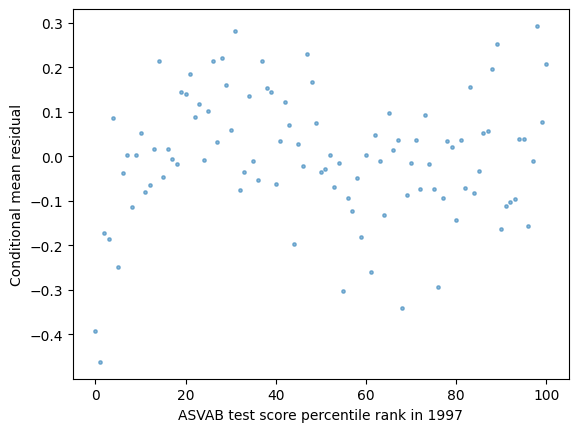

In [20]:
df = merged_df.copy()

df = df[['log_hpay', 'ASVAB_pct']].dropna(axis=0, how='any').sort_values(by='ASVAB_pct').copy()
df['log_hpay_hat'] = results_f.predict(df)
df['residual'] = df['log_hpay'] - df['log_hpay_hat']


df['ASVAB_pct_bin'] = np.floor(df['ASVAB_pct'])
df_plot = df.groupby('ASVAB_pct_bin').agg(mean_residual = ('residual', 'mean')).reset_index().sort_values('ASVAB_pct_bin').copy()

fig, ax = plt.subplots()
ax.scatter(x=df_plot['ASVAB_pct_bin'], y=df_plot['mean_residual'], s=6, alpha=0.5)
ax.set_ylabel('Conditional mean residual')
ax.set_xlabel('ASVAB test score percentile rank in 1997')

The residuals are clearly not mean independent of the regressor.

However, the best linear approximation of the conditional mean of the residuals given the regressor is simply a horizontal line at zero. They are uncorrelated. This can be verified numerically:

In [21]:
df = merged_df.copy()

df = df[['log_hpay', 'ASVAB_pct']].dropna(axis=0, how='any').sort_values(by='ASVAB_pct').copy()
df['log_hpay_hat'] = results_f.predict(df)
df['residual'] = df['log_hpay'] - df['log_hpay_hat']

covariance = df['ASVAB_pct'].cov(df['residual'])
np.isclose(covariance, 0)
# df = df[['residual', 'ASVAB_pct']].dropna(axis=0, how='any').copy()
# df = df.astype(float)
# np.isclose(
#     np.cov(m=df, rowvar=False)[0,1],
#     0
# )


np.True_

Residuals here
 - are not mean independent from the regressor
 - but they are by construction uncorrelated with the regressor

Good illustration: uncorrelatedness does not imply mean independence


**Goodness of fit**

A common measure of model fit is the $R^2$ statistic.

It measures the share of the variance of the outcome variable that is explained by the model.

To understand this statistic, notice that the observed outcome can be decomposed as

$$
Y = \widehat{Y} + \widehat{u}
$$

where $\widehat{Y}$ denotes the predicted values and $\widehat{u}$ the residuals.

For our example, this decomposition corresponds to:

$$
log\_hpay_{i} 
\ =\ \widehat{log\_hpay}_{i} + \widehat{u}_{i}
$$

Moreover, because the predicted values are linear combinations of the regressors and the residuals are uncorrelated with the regressors, the fitted values and residuals are also uncorrelated:

$$
Cov_{Sample}(\widehat{Y},\widehat{u}) = 0.
$$

In our example, this becomes:
$$
Cov_{Sample}(\widehat{log\_hpay}_{i}, \widehat{u}_{i}) = 0
$$

Let us verify this numerically.

In [22]:
df = merged_df.copy()

df = df[['log_hpay', 'ASVAB_pct']].dropna(axis=0, how='any').sort_values(by='ASVAB_pct').copy()
df['log_hpay_hat'] = results_f.predict(df)
df['residual'] = df['log_hpay'] - df['log_hpay_hat']
covariance = df['log_hpay_hat'].cov(df['residual'])
np.isclose(covariance, 0)


np.True_

Because the predicted values of the outcome variable and the residuals are uncorrelated, the variance of the outcome can be decomposed as follows:

$$
Var_{Sample}(Y) = Var_{Sample}(\widehat{Y} + \widehat{u}) = Var_{Sample}(\widehat{Y}) + Var_{Sample}(\widehat{u})
$$

The $R^2$ statistic corresponds to the ratio of the variance of the predicted values of the outcome variable to the variance of the outcome variable:

$$
R^2 = \frac{Var_{Sample}(\widehat{Y})}{Var_{Sample}(Y)} 
$$

**In the case of the simple linear regression model**, it can be shown that the $R^2$ statistic is equal to the square of the correlation coefficient between the outcome variable and the regressor:

$$
R^2 = (Corr_{Sample}(X, Y))^2
$$

In our example, the equivalence corresponds to:

$$
R^2 = \frac{Var_{Sample}(\widehat{log\_hpay})}{Var_{Sample}(log\_hpay)}  = (Corr_{Sample}(ASVAB\_pct, log\_hpay))^2
$$

Let us verify this equivalence numerically.

In [23]:
df = merged_df.copy()


df = (
    df[['log_hpay', 'ASVAB_pct']]
        .dropna(axis=0, how='any')
        .sort_values(by='ASVAB_pct')
        .copy()
)
# predicted values Y_hat
df['log_hpay_hat'] = results_f.predict(df)

# variance decomposition interpretation --> Var(predicted outcome) / Var(actual outcome) 
R2_variance_decomposition = df['log_hpay_hat'].var() / df['log_hpay'].var()
# in the case of the simple linear regression:
#  -> correlation coefficient: correlation coefficient squared
R2_correlation_squared = (df['ASVAB_pct'].corr(df['log_hpay'])) ** 2
print('R2 variance decomposition:', R2_variance_decomposition, 
      '\nR2 correlation squared:', R2_correlation_squared)


R2 variance decomposition: 0.13937888430960596 
R2 correlation squared: 0.13937888430960643


In our sample, the simple linear regression model using the ASVAB test score percentile rank as the only regressor explains about 13.9% of the variation in log hourly pay.

Note that in the case of simple linear regression with an intercept, the slope coefficient estimate and the $R^2$ statistic are both directly related to the sample correlation coefficient.

The $R^2$ statistic is simply the squared sample correlation:

$$
R^2 = \left(Corr_{Sample}(X,Y)\right)^2
$$

The slope coefficient estimate can also be expressed in terms of the sample correlation coefficient:

$$
\widehat{\beta}_1
=
Corr_{Sample}(X,Y)
\cdot
\frac{SD_{Sample}(Y)}{SD_{Sample}(X)}
$$



Above, we have seen that hourly pay in 2023 is positively associated with test score percentile ranks in 1997.

Test scores and education are themselves associated.

Therefore, the association between hourly pay and test scores may differ once education is held constant.

Does this relationship still hold when holding highest level of education constant? 

(This question may or may not make sense. Let us consider the example here as an illustration.)

To investigate this question, we would like to compare individuals with different test scores but the same level of education in terms of their hourly pay.

One possibility would be to estimate a separate simple linear regression for each education group. Sometimes this is the right approach.

Let us first consider this approach in a simple case.

Let us define the variable `bachelor_plus` as a binary indicator (or dummy) variable:

$$
bachelor\_plus =
\begin{cases}
1 & \text{ if }  educ\_cat = \text{Bachelor Plus} \\
0 & \text{ otherwise }
\end{cases}

$$

In [24]:
df = merged_df.copy()
df['bachelor_plus'] = np.where(df['educ_cat'].eq('Bachelor Plus'),
                               1, # Bachelor Plus --> 1
                               np.where(df['educ_cat'].notna(),
                                        0, # Not missing, not Bachelor Plus --> 0
                                        pd.NA) # Missing value --> Missing
                               )

merged_df = df.copy()

Let us run simple linear regressions separately for each value of `bachelor_plus` as well as without conditioning on education.

In [25]:
df = merged_df.copy()

df = (
    df[["log_hpay", "ASVAB_pct", "bachelor_plus"]]
    .dropna()
    .sort_values("ASVAB_pct")
    .copy()
)

df["ASVAB_pct_bin"] = np.floor(df["ASVAB_pct"])


# dictionary {}
groups = {
    "Bachelor Plus": df[df["bachelor_plus"].eq(1)].copy(),
    "Without Bachelor": df[df["bachelor_plus"].eq(0)].copy(),
    "Unconditional": df.copy()
}

models = {}
cond_means = {}

for group_name, group_df in groups.items():
    # for each sample restriction
    # run the same simple linear regression 
    model = smf.ols(
        formula="log_hpay ~ ASVAB_pct",
        data=group_df
    ).fit()

    # collect the predicted values --> plotting the regression line
    groups[group_name]["log_hpay_hat"] = model.predict(group_df)
    # collect the model --> model statistics (parameters beta_0, beta_1)
    models[group_name] = model

    # conditional means per regressor bins
    cond_means[group_name] = (
        group_df
        .groupby("ASVAB_pct_bin")
        .agg(mean_log_hpay=("log_hpay", "mean"))
        .reset_index()
        .sort_values("ASVAB_pct_bin")
        .copy()
    )

colors = {
    "Bachelor Plus": "purple",
    "Without Bachelor": "blue",
    "Unconditional": "black"
}

reg_line_labels = {}

for group_name in groups.keys():
    intercept = models[group_name].params["Intercept"]
    slope = models[group_name].params["ASVAB_pct"]

    reg_line_labels[group_name] = (
        f"{group_name}: "
        f"log_hpay_hat = {intercept:.2f} + {slope:.4f} * ASVAB_pct"
    )

Let us plot the simple linear regression lines together with the corresponding scatter plots.

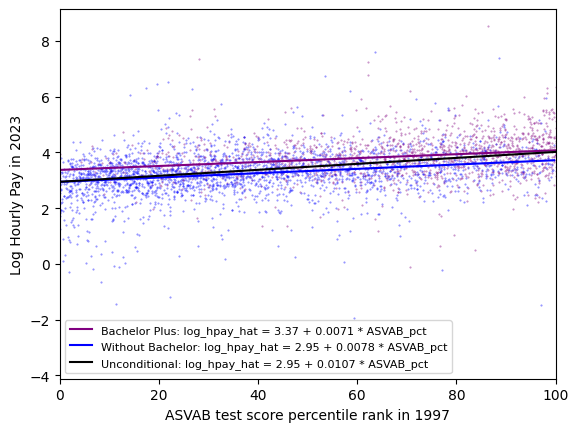

In [26]:
fig, ax = plt.subplots()


for group_name in ["Bachelor Plus", "Without Bachelor"]:
    ax.scatter(
        x=groups[group_name]["ASVAB_pct"],
        y=groups[group_name]["log_hpay"],
        s=0.2,
        alpha=0.5,
        color=colors[group_name]
    )    

for group_name, group_df in groups.items():
    
    ax.plot(
        group_df["ASVAB_pct"],
        group_df["log_hpay_hat"],
        color=colors[group_name],
        label=reg_line_labels[group_name]
    )

ax.set_ylabel("Log Hourly Pay in 2023", fontsize=10)
ax.set_xlabel("ASVAB test score percentile rank in 1997")
ax.set_xlim(left=0, right=100)
ax.legend(fontsize=8)


Let us plot the regression lines this time with the corresponding conditional means. 

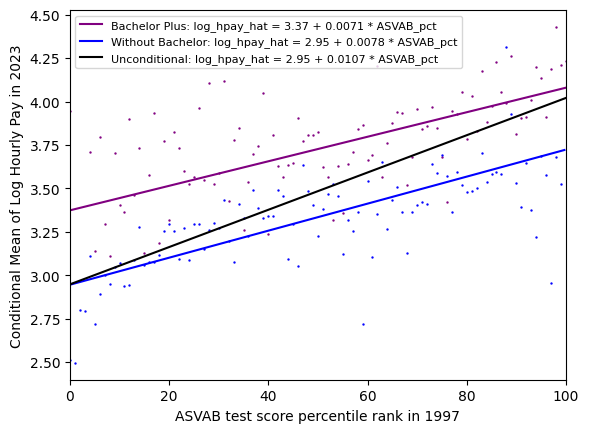

In [27]:

fig, ax = plt.subplots()


for group_name in ["Bachelor Plus", "Without Bachelor"]:
    ax.scatter(
        x=cond_means[group_name]["ASVAB_pct_bin"],
        y=cond_means[group_name]["mean_log_hpay"],
        s=0.5,
        alpha=1,
        color=colors[group_name]
    )    

for group_name, group_df in groups.items():
    
    ax.plot(
        group_df["ASVAB_pct"],
        group_df["log_hpay_hat"],
        color=colors[group_name],
        label=reg_line_labels[group_name]
    )

ax.set_ylabel('Conditional Mean of Log Hourly Pay in 2023', fontsize=10)
ax.set_xlabel('ASVAB test score percentile rank in 1997')
ax.set_xlim(left=0, right=100)


ax.legend(fontsize=8)


We can tentatively conclude that the positive association between log hourly pay and test score percentile ranks is weaker within education groups than in the overall sample.

Recall that our objective was to look at how the association between hourly pay and test scores changes once education is held constant.

Sometimes, however,
 - we would like to obtain an average answer to this question;
 - we might want to consider many education groups;
 - we might also be interested in how hourly pay is associated with education once test scores are held constant;
 - we might want to control for additional variables besides education.

This provides the motivation for a more flexible framework, **multiple linear regression**, a natural extension of simple linear regression.

**Multiple linear regression with two regressors**

Let us begin with the case of two regressors.

As before, let us interpret the population model as a linear approximation to the conditional mean function of the outcome variable given the regressors:

$$
\mathbb{E}[Y \mid X_1, X_2]\ \ \approx\ \
\overbrace{\beta_0}^{\mathclap{\substack{\text{intercept}\\ \text{parameter}}}}\ \ +\ \
\overbrace{\beta_1}^{\mathclap{\substack{\text{coefficient}\\ \text{parameter}\\ \text{for } X_1}}} \cdot X_1 \ \ +\ \ 
\overbrace{\beta_2}^{\mathclap{\substack{\text{coefficient}\\ \text{parameter}\\ \text{for } X_2}}} \cdot X_2
$$


**Ordinary Least Squares in the case of Multiple Linear Regression with two regressors**

As before, we choose the best-fitting linear function by minimising the mean of squared errors:

$$
(\beta_0, \beta_1, \beta_2) = \arg \underset{(b_0, b_1, b_2)}{\min} \  \mathbb{E}\left[\left(Y - (b_0 + b_1 \cdot X_1 + b_2 \cdot X_2)\right)^2\right] 
$$

Compared to simple linear regression, nothing fundamental has changed. We now minimise squared residuals over three parameters instead of two.

The **error term** is the deviation between the value of the outcome variable and the linear prediction for the conditional mean:

$$
\underbrace{\varepsilon}_{\mathclap{\substack{\text{error}\\ \text{term}}}}\ =\ 
\underbrace{Y}_{\mathclap{\substack{\text{outcome}}}} - 
\underbrace{(\beta_0 + \beta_1 \cdot X_1 + \beta_2 \cdot X_2)}_{\mathclap{\substack{\text{linear prediction}}}} 
\ \ \ \ \ \Longleftrightarrow \ \ \ \ \  
\underbrace{Y}_{\mathclap{\substack{\text{outcome}}}}\ =\ \underbrace{\beta_0 + \beta_1 \cdot X_1 + \beta_2 \cdot X_2}_{\mathclap{\substack{\text{linear prediction}}}} + \underbrace{\varepsilon}_{\mathclap{\substack{\text{error}\\ \text{term}}}}
$$

After solving the OLS minimisation problem, the coefficient parameters for the best linear approximation satisfy the following system of equations:

$$
\begin{array}{rclcrcll}
\mathbb{E}[\varepsilon] &=& 0 & \Longleftrightarrow & \beta_0 &=& \mathbb{E}[Y] - \beta_1 \cdot \mathbb{E}[X_1] - \beta_2 \cdot \mathbb{E}[X_2] & \ \ (\text{intercept}) \\ \\
Cov(X_1, \varepsilon) &=& 0   & \Longleftrightarrow &   \beta_1  &=& \frac{Cov(X_1, Y)}{Var(X_1)} - \beta_2 \cdot \frac{Cov(X_1, X_2)}{Var(X_1)}   &  \ \ (\text{zero covariance condition 1}) \\ \\
Cov(X_2, \varepsilon) &=& 0   & \Longleftrightarrow &   \beta_2  &=& \frac{Cov(X_2, Y)}{Var(X_2)} - \beta_1 \cdot \frac{Cov(X_1, X_2)}{Var(X_2)}   &  \ \ (\text{zero covariance condition 2})
\end{array}
$$

The conditions look familiar from the simple linear regression case. The expression for the intercept follows directly from the zero unconditional mean error, $\mathbb{E}[\varepsilon] =0$. Likewise, the error term has zero covariance with each regressor. These zero covariance conditions are a consequence of defining the linear regression function as the best linear approximation to the conditional mean function.

The specific formulas for coefficients $\beta_1$ and $\beta_2$ are now more complicated. They are nevertheless related to simple linear regression coefficients. Let us come back to this question later.



**Multiple linear regression in our simple case**

In our example, the population linear approximation can be written as:

$$
log\_hpay \ =\ \beta_0 + \beta_1 \cdot ASVAB\_pct + \beta_2 \cdot bachelor\_plus + \varepsilon
$$

Remark: Since the linear prediction is now different, the error term $\varepsilon$ is generally different as well.

The candidate residuals as a function of candidate linear prediction parameters $(b_0, b_1, b_2)$ are now:

$$
u_{i}(b_0, b_1, b_2) = log\_hpay_{i} - (b_0 + b_1 \cdot ASVAB\_pct_{i} + b_2 \cdot bachelor\_plus_{i}) \ \ \ (\text{for each } i \in Sample)
$$

And the OLS minimisation becomes:

$$
\begin{array}{crcl}
&
(\widehat{\beta}_0, \widehat{\beta}_1, \widehat{\beta}_2) 
&=& \arg \underset{(b_0, b_1, b_2)}{\min} \  \displaystyle\frac{1}{N} \sum_{i \in Sample} \left(u_{i}(b_0, b_1, b_2)\right)^2 \\ \\
\Longleftrightarrow &
(\widehat{\beta}_0, \widehat{\beta}_1, \widehat{\beta}_2) 
&=& \arg \underset{(b_0, b_1, b_2)}{\min} \  \displaystyle\frac{1}{N} \sum_{i \in Sample} \left(log\_hpay_{i} - (b_0 + b_1 \cdot ASVAB\_pct_{i} + b_2 \cdot bachelor\_plus_{i})\right)^2 
\end{array}
$$

And by analogy, the resulting parameter estimates satisfy:

$$
\begin{array}{rclcrcll}
\frac{1}{N} \sum_{i \in Sample} \widehat{u}_{i} &=& 0  & \Longleftrightarrow & \widehat{\beta}_0 &=& \frac{1}{N} \sum_{i \in Sample} log\_hpay_{i} - \widehat{\beta}_1 \cdot \frac{1}{N} \sum_{i \in \text{Sample}} ASVAB\_pct_{i} -  \widehat{\beta}_2 \cdot \frac{1}{N} \sum_{i \in \text{Sample}} bachelor\_plus_{i} & \ \ (\text{intercept}) \\ \\
Cov_{Sample}(ASVAB\_pct, \widehat{u}) &=& 0  & \Longleftrightarrow & \widehat{\beta}_1 &=&  \frac{Cov_{Sample}(ASVAB\_pct,log\_hpay)}{Var_{Sample}(ASVAB\_pct)} - \widehat{\beta}_2 \cdot \frac{Cov_{Sample}(ASVAB\_pct,bachelor\_plus)}{Var_{Sample}(ASVAB\_pct)}  &  \ \ (\text{zero covariance condition 1}) \\ \\
Cov_{Sample}(bachelor\_plus, \widehat{u}) &=& 0  & \Longleftrightarrow & \widehat{\beta}_2 &=&  \frac{Cov_{Sample}(bachelor\_plus,log\_hpay)}{Var_{Sample}(bachelor\_plus)} - \widehat{\beta}_1 \cdot \frac{Cov_{Sample}(ASVAB\_pct,bachelor\_plus)}{Var_{Sample}(bachelor\_plus)}  &  \ \ (\text{zero covariance condition 2})
\end{array}
$$

The estimated equation can be written as:

$$
\begin{array}{crcl}
&\underbrace{log\_hpay_{i}}_{\mathclap{\substack{\text{actual outcome}}}} \ &=&\  \underbrace{\widehat{log\_hpay}_{i}}_{\mathclap{\substack{\text{predicted outcome}}}} + \underbrace{\widehat{u}_{i}}_{\mathclap{\substack{\text{residual}}}}  \\ \\ 
\Longleftrightarrow  & \underbrace{log\_hpay_{i}}_{\mathclap{\substack{\text{actual outcome}}}} & = &   \underbrace{\widehat{\beta}_0 + \widehat{\beta}_1 \cdot ASVAB\_pct_{i} + \widehat{\beta}_2 \cdot bachelor\_plus_{i}}_{\mathclap{\substack{\text{linear prediction}}}} + \underbrace{\widehat{u}_{i}}_{\mathclap{\substack{\text{residual}}}} \\ \\ 
\end{array}
$$

The predicted value of log hourly pay for individual $i$ corresponds to:

$$
\underbrace{\widehat{log\_hpay}_{i}}_{\mathclap{\substack{\text{predicted outcome}}}} 
\ =\ \underbrace{log\_hpay_{i}}_{\mathclap{\substack{\text{actual outcome}}}} - \underbrace{\widehat{u}_{i}}_{\mathclap{\substack{\text{residual}}}} 
\ =\ \widehat{\beta}_0 + \widehat{\beta}_1 \cdot ASVAB\_pct_{i} + \widehat{\beta}_2 \cdot bachelor\_plus_{i} 

$$





Let us carry out the OLS estimation for the multiple linear regression model.

As in the simple linear regression case, we have two options when using `statsmodels`:

 - the arrays interface;
 - the formula interface.

Let us implement both.

In [28]:
df = merged_df.copy()
# outcome: log hourly pay
outcome = 'log_hpay'
# two regressors: 
#  - ASVAB test score percentile rank, 
#  - Bachelor Plus dummy (1/0) for education
regressors = ['ASVAB_pct', 'bachelor_plus']

df = df[[outcome] + regressors].dropna(axis=0, how='any').copy()
df = df.astype(float)

y = df[outcome].copy()
X = df[regressors].copy()
X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())


                            OLS Regression Results                            
Dep. Variable:               log_hpay   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     422.1
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          5.42e-167
Time:                        19:33:45   Log-Likelihood:                -4570.9
No. Observations:                3984   AIC:                             9148.
Df Residuals:                    3981   BIC:                             9167.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             2.9551      0.024    123.730

In [29]:
df = merged_df.copy()
# outcome: log hourly pay
outcome = 'log_hpay'
# two regressors: 
#  - ASVAB test score percentile rank, 
#  - Bachelor Plus dummy (1/0) for education
regressors = ['ASVAB_pct', 'bachelor_plus']

# specifying the formula
# lm() function in R
reg_formula = 'log_hpay ~ ASVAB_pct + bachelor_plus'

df = df[[outcome] + regressors].dropna(axis=0, how='any').copy()
df = df.astype(float)

model = smf.ols(formula=reg_formula,
                data=df)
results_f = model.fit()

print(results_f.summary())


                            OLS Regression Results                            
Dep. Variable:               log_hpay   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     422.1
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          5.42e-167
Time:                        19:33:46   Log-Likelihood:                -4570.9
No. Observations:                3984   AIC:                             9148.
Df Residuals:                    3981   BIC:                             9167.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         2.9551      0.024    123.730

In [30]:
np.exp(results_f.params['bachelor_plus'])

np.float64(1.4731099405953696)

The estimated equation becomes:

$$
\widehat{log\_hpay}_{i} \ =\ 2.95 + 0.0075 \cdot ASVAB\_pct_{i} + 0.387 \cdot bachelor\_plus_{i} 
$$

Interpretation of $\widehat{\beta}_0 = 2.95$:
 - The predicted log hourly pay in 2023 for individuals without a Bachelor's degree (`bachelor_plus = 0`) who scored the lowest possible test score (`ASVAB_pct = 0`) in 1997. As before, the intercept is not particularly meaningful in this application.

Interpretation of $\widehat{\beta}_1 = 0.0075$:
 - Holding constant whether an individual has a Bachelor's degree, scoring one percentile point higher on the test in 1997 is associated with an average increase of approximately 0.75% in hourly pay. ($100 \cdot (e^{0.0075} - 1) \approx 0.75$)

Interpretation of $\widehat{\beta}_2 = 0.3874$:
 - Holding constant the test score percentile rank in 1997, individuals with a Bachelor's degree (`bachelor_plus = 1`) are associated, on average, with 47.3% higher hourly pay than individuals without a Bachelor's degree (`bachelor_plus = 0`). ($100 \cdot (e^{0.387} - 1) \approx 47.3$) 

When interpreting a coefficient, all other regressors are thought of as being held constant.



multiple linear regression is a symmetric framework mathematically

the main regressor / the regressor of interest depends on the question
--> what we would like to look at

relative to the main regressor, the other regressors included in the regression
--> control variables

what is the associated difference on average in log hourly pay between bachelor holders and people who do not hold a bachelor's degree holding test score percentile rank at age 13-17 constant / controlling for test score percentile rank at age 13-17 
--> bachelor_plus --> main regressor
--> ASVAB_pct --> control variable




**Control variables, covariates**

From a mathematical point of view, multiple linear regression is symmetric with respect to the regressors.

The interpretation of each coefficient focuses on its corresponding regressor while the remaining regressors are held constant.

When interpreting the coefficient associated with a particular regressor, the remaining regressors are often referred to as **control variables** or **covariates**.

A corresponding expression, commonly used in econometrics, is **controlling for**. Using this terminology, the interpretation of $\widehat{\beta}_1 = 0.0075$ can be reformulated as follows:
 - **Controlling for** whether an individual has a Bachelor's degree, scoring one percentile point higher on the test in 1997 is associated with an average increase of approximately 0.75% in hourly pay. ($100 \cdot (e^{0.0075} - 1) \approx 0.75$)

In this context, _controlling for_ can be understood as a synonym for _holding constant_.

The term control variable refers to the role of a regressor in the interpretation of another coefficient and therefore depends on the research question. It does not mean that some variables are permanently control variables while others are not. However, within a particular research context, some variables may consistently serve as control variables.


**What determines whether the coefficients between simple linear regression and multiple linear regression differ?**

We have seen that in the log-earnings regressions the coefficient on the test score percentile rank variable `ASVAB_pct` is smaller in magnitude in the case of the multiple linear regression (when controlling for holding a Bachelor's degree or not) relative to the case of the simple linear regression (without any controls): $\widehat{\beta}^{\text{MLR}}_1 \approx 0.0075$ versus $\widehat{\beta}^{\text{SLR}}_1 \approx 0.0108$.

It turns out, there is a simple relationship between: 
 - the coefficient estimates for the multiple linear regression;
 - the coefficient estimate for the simple linear regression involving the outcome and the main regressor;
 - the coefficient estimate for the simple linear regression involving the control variable and the main regressor.

To see this, let us remind ourselves of the zero covariance condition for the main regressor $X_1$:

$$
\begin{array}{crcl}
 &\overbrace{\beta_1}^{\mathclap{\substack{\text{coefficient}\\ \text{MLR}\\ X_1\\ \text{main regressor}}}} \ \ &=& \ \ 
\underbrace{\frac{Cov(X_1, Y)}{Var(X_1)}}_{\mathclap{\substack{\text{slope coefficient}\\ \text{SLR}\\ Y \sim X_1}}} \ \ - \ \ 
\overbrace{\beta_2}^{\mathclap{\substack{\text{coefficient}\\ \text{MLR}\\ X_2\\ \text{control variable}}}} \ \cdot \ 
\underbrace{\frac{Cov(X_1, X_2)}{Var(X_1)}}_{\mathclap{\substack{\text{slope coefficient}\\ \text{SLR}\\ X_2 \sim X_1}}} \\ \\ \\
\Longleftrightarrow  & \beta_1^{Y \sim X_1 + X_2} \ \ &=& \ \ 
\beta_1^{Y \sim X_1} \ \ - \ \ 
\beta_2^{Y \sim X_1 + X_2} \ \cdot \ 
\beta_1^{X_2 \sim X_1}
\end{array}
$$

In our example:
 - $\beta_1^{Y \sim X_1}$ is the slope coefficient in the simple linear regression of the outcome `log_hpay` ($Y$) on the main regressor `ASVAB_pct` ($X_1$): 
$$
log\_hpay = \beta_0^{Y \sim X_1} + \beta_1^{Y \sim X_1} \cdot ASVAB\_pct + \varepsilon^{Y \sim X_1}
$$
 - $\beta_1^{X_2 \sim X_1}$ is the slope coefficient in the simple linear regression of the control variable `bachelor_plus` ($X_2$) on the main regressor `ASVAB_pct` ($X_1$):
$$
bachelor\_plus = \beta_0^{X_2 \sim X_1} + \beta_1^{X_2 \sim X_1} \cdot ASVAB\_pct + \varepsilon^{X_2 \sim X_1}
$$
 - $\beta_1^{Y \sim X_1 + X_2}$ and $\beta_2^{Y \sim X_1 + X_2}$ are coefficients from the multiple linear regression of the outcome `log_hpay` ($Y$) on the main regressor `ASVAB_pct` ($X_1$) and the control variable `bachelor_plus` ($X_2$):
$$
log\_hpay = \beta_0^{Y \sim X_1 + X_2} + \beta_1^{Y \sim X_1 + X_2} \cdot ASVAB\_pct + \beta_2^{Y \sim X_1 + X_2} \cdot bachelor\_plus + \varepsilon^{Y \sim X_1 + X_2}
$$

Rearranging gives:

$$
\underbrace{\beta_1^{Y \sim X_1}}_{\mathclap{\substack{\text{coefficient without}\\ \text{controlling for}\\ bachelor\_plus\ (X_2)}}}\ \ \ \ \ = \ \ \ \ 
\underbrace{\beta_1^{Y \sim X_1 + X_2}}_{\mathclap{\substack{\text{coefficient when}\\ \text{controlling for}\\ bachelor\_plus\ (X_2)}}} \ \ \ \ \ +\ \ \ \ \ 
\underbrace{\beta_2^{Y \sim X_1 + X_2} \cdot \beta_1^{X_2 \sim X_1}}_{\mathclap{\substack{\text{difference}}}}
$$

The difference $\beta_2^{Y \sim X_1 + X_2} \cdot \beta_1^{X_2 \sim X_1}$ is sometimes called the **omitted variable bias**. However, the exact meaning of this name depends on the context. Bias relative to what? What is the point of comparison? In the current approximation context: bias relative to the situation where the variable is included as a control variable. In the current approximation framework, there is no notion of a "true" linear model. We have different approximations of the conditional mean of `log_hpay` using different sets of regressors / conditioning variables.

Let us verify that this is indeed the case for our example.

According to the above relationship, the omitted variable bias should equal

 - the coefficient on the control variable `bachelor_plus` ($X_2$) when controlling for it: $\beta_2^{Y \sim X_1 + X_2}$
 - the slope coefficient on the main regressor `ASVAB_pct` ($X_1$) in the simple linear regression of the control variable `bachelor_plus` ($X_2$) on the main regressor `ASVAB_pct` ($X_1$): $\beta_1^{X_2 \sim X_1}$

In [31]:

df = merged_df.copy()

outcome = 'log_hpay'
regressors = ['ASVAB_pct', 'bachelor_plus']

df = df[[outcome] + regressors].dropna(axis=0, how='any').copy()
df = df.astype(float)

formulas = {
    # MLR
    'Y_X1_X2': 'log_hpay ~ ASVAB_pct + bachelor_plus',
    # SLR
    'Y_X1': 'log_hpay ~ ASVAB_pct',
    # auxiliary SLR
    'X2_X1': 'bachelor_plus ~ ASVAB_pct',
}

coefs = {}

for formula_name, formula in formulas.items():
    results = smf.ols(formula=formula, data=df).fit()
    coefs[formula_name] = results.params

coefficient_difference = coefs['Y_X1']['ASVAB_pct'] - coefs['Y_X1_X2']['ASVAB_pct']

omitted_variable_bias = coefs['Y_X1_X2']['bachelor_plus'] * coefs['X2_X1']['ASVAB_pct']

print(f'Coefficient difference (SLR - MLR): {coefficient_difference}')
print(f'Omitted variable bias:              {omitted_variable_bias}')
print(f'Equal? {np.isclose(coefficient_difference, omitted_variable_bias)}')

Coefficient difference (SLR - MLR): 0.0032066992163500823
Omitted variable bias:              0.0032066992163501252
Equal? True


MLR coefficient: 0.0108
SLR coefficient: 0.0075
Difference is about 0.0033

The technical question of omitted variable bias may arise in the following contexts:
 - When we cannot observe a specific variable:
   - Under what conditions would the estimated coefficient change if we could control for it?
 - When model complexity must be limited (e.g., because the number of potential regressors is large relative to the sample size):
   - Does omitting them affect the coefficients of interest?

General technical question:
 - Is it really a problem if we do not or cannot control for a particular variable?

Remark:
 - Deciding whether to include a variable as a regressor is not merely a mechanical decision.
 - The answer depends on the question we want to answer.
 - Prediction:
   - A pragmatic, performance-oriented approach is often appropriate.
 - Understanding economic mechanisms / causal interpretation:
   - We need to think carefully about which variables should and should not be controlled for.


**Flexibility of multiple linear regression**

Multiple linear regression is a flexible framework because the model only has to be linear in the parameters (the $\beta$-s).

The regressors themselves can be transformed and combined in many ways.

In our current simple model:

$$
log\_hpay \ =\ \beta_0 + \beta_1 \cdot ASVAB\_pct + \beta_2 \cdot bachelor\_plus + \varepsilon
$$

we control for the dummy variable `bachelor_plus` in addition to the main regressor `ASVAB_pct`.

This model can be interpreted as estimating two simple linear regressions of `log_hpay` on `ASVAB_pct`:
 - one for individuals without a Bachelor's degree (`bachelor_plus=0`);
 - one for individuals with a Bachelor's degree (`bachelor_plus=1`);
 - both regressions have the same slope but different intercepts.

If we include an interaction (product) between the continuous regressor `ASVAB_pct` and the dummy regressor `bachelor_plus`,

$$
log\_hpay \ =\ \beta_0 + \beta_1 \cdot ASVAB\_pct + \beta_2 \cdot bachelor\_plus + \beta_3 \cdot ASVAB\_pct \cdot bachelor\_plus + \varepsilon,
$$

the two groups are allowed to have both different intercepts and different slopes.

For `bachelor_plus=0`, the equation becomes:

$$
log\_hpay \ =\ \beta_0 + \beta_1 \cdot ASVAB\_pct + \varepsilon.
$$

For `bachelor_plus=1`, the equation becomes:

$$
log\_hpay \ =\ (\beta_0 + \beta_2) + (\beta_1 + \beta_3) \cdot ASVAB\_pct + \varepsilon.
$$

Let us implement both models.


In [32]:
df = merged_df.copy()

outcome = 'log_hpay'
regressors = ['ASVAB_pct', 'bachelor_plus']

df = (
    df[[outcome] + regressors]
    .dropna()
    .astype(float)
    .copy()
)

formulas = {
    'parallel_lines': 'log_hpay ~ ASVAB_pct + bachelor_plus',
    'different_slopes': 'log_hpay ~ ASVAB_pct * bachelor_plus',
}

params = {}
results = {}
for model_name, formula in formulas.items():
    results[model_name] = smf.ols(formula=formula, data=df).fit()
    params[model_name] = results[model_name].params

print(
    'Model with parallel regression lines:',
    params['parallel_lines'],
    '',
    'Model with different slopes:',
    params['different_slopes'],
    sep='\n',
)

Model with parallel regression lines:
Intercept        2.955125
ASVAB_pct        0.007523
bachelor_plus    0.387376
dtype: float64

Model with different slopes:
Intercept                  2.945407
ASVAB_pct                  0.007778
bachelor_plus              0.428128
ASVAB_pct:bachelor_plus   -0.000719
dtype: float64


For the equal-slopes model, we obtained:

$$
\widehat{log\_hpay} \ =\ 2.95 + 0.0075 \cdot ASVAB\_pct + 0.387 \cdot bachelor\_plus
$$

For the fully flexible model, we obtained:

$$
\widehat{log\_hpay} \ =\ 2.945 + 0.0077 \cdot ASVAB\_pct + 0.428 \cdot bachelor\_plus - 0.00072 \cdot ASVAB\_pct \cdot bachelor\_plus.
$$

The estimated interaction coefficient ($-0.00072$) is small in magnitude. Consequently, here there is little evidence that the association between test score percentile rank and hourly pay differs substantially between individuals with and without a Bachelor's degree.

For this reason, the simpler equal-slopes model appears to provide an adequate approximation here.

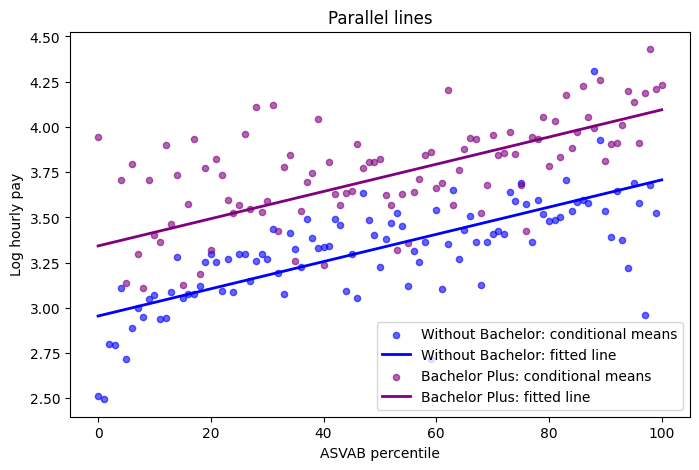

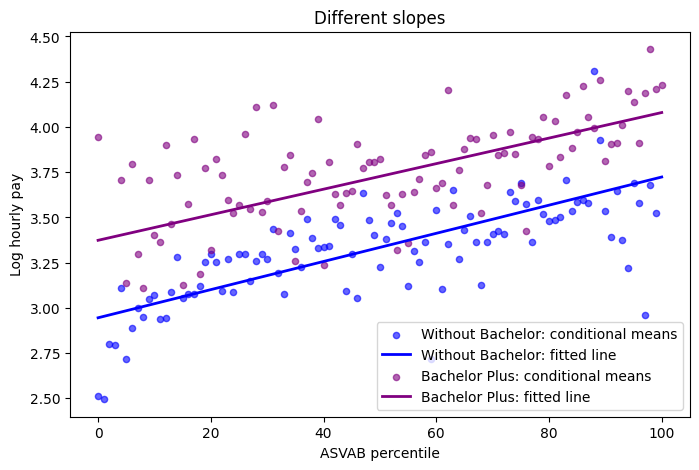

In [33]:
df = merged_df.copy()

outcome = 'log_hpay'
regressors = ['ASVAB_pct', 'bachelor_plus']

df = (
    df[[outcome] + regressors]
    .dropna()
    .astype(float)
    .sort_values('ASVAB_pct')
    .copy()
)

df['ASVAB_pct_bin'] = np.floor(df['ASVAB_pct'])

formulas = {
    'Parallel lines': 'log_hpay ~ ASVAB_pct + bachelor_plus',
    'Different slopes': 'log_hpay ~ ASVAB_pct * bachelor_plus',
}

results = {
    model_name: smf.ols(formula=formula, data=df).fit()
    for model_name, formula in formulas.items()
}

groups = {
    'Without Bachelor': 0,
    'Bachelor Plus': 1,
}

colors = {
    'Without Bachelor': 'blue',
    'Bachelor Plus': 'purple',
}

x_grid = np.linspace(
    df['ASVAB_pct'].min(),
    df['ASVAB_pct'].max(),
    100
)

cond_means = {}

for group_name, bachelor_value in groups.items():
    group_df = df[df['bachelor_plus'].eq(bachelor_value)].copy()

    cond_means[group_name] = (
        group_df
        .groupby('ASVAB_pct_bin')
        .agg(
            mean_log_hpay=('log_hpay', 'mean'),
            n=('log_hpay', 'size')
        )
        .reset_index()
        .sort_values('ASVAB_pct_bin')
    )

for model_name, result in results.items():

    fig, ax = plt.subplots(figsize=(8, 5))

    for group_name, bachelor_value in groups.items():

        # Conditional means from actual data
        cm = cond_means[group_name]

        ax.scatter(
            cm['ASVAB_pct_bin'],
            cm['mean_log_hpay'],
            s=20,
            alpha=0.6,
            color=colors[group_name],
            label=f'{group_name}: conditional means'
        )

        # Prediction grid
        pred_df = pd.DataFrame({
            'ASVAB_pct': x_grid,
            'bachelor_plus': bachelor_value
        })

        pred_df['log_hpay_hat'] = result.predict(pred_df)

        ax.plot(
            pred_df['ASVAB_pct'],
            pred_df['log_hpay_hat'],
            color=colors[group_name],
            linewidth=2,
            label=f'{group_name}: fitted line'
        )

    ax.set_title(model_name)
    ax.set_xlabel('ASVAB percentile')
    ax.set_ylabel('Log hourly pay')
    ax.legend()
    plt.show()